In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the car sales dataset using a raw string to avoid issues with backslashes in the file path
df = pd.read_csv(r'C:\file_path.csv')

In [21]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


## Data Cleaning

In [22]:
# Store the original number of rows
original_count = df.shape[0]

# Remove duplicates
df = df.drop_duplicates()

# Store the new number of rows
new_count = df.shape[0]

# Calculate the number of duplicates removed
duplicates_removed = original_count - new_count

# Print the number of duplicates removed
print(f"Total {duplicates_removed} duplicates were removed.")

Total 0 duplicates were removed.


## Descriptive Statistics

In [23]:
# Rename the column 'Price ($)' to 'Price'
df = df.rename(columns={'Price ($)': 'Price'})

In [24]:
# Calculate the range of the 'Annual Income' column
range_value = df['Annual Income'].max() - df['Annual Income'].min()
print(f"Annual Income Range: {range_value}")

# Get descriptive statistics for the 'Annual Income' column
annual_income_statistics = df['Annual Income'].describe()
print(annual_income_statistics)

# Calculate the range of the 'Price' column
range_value = df['Price'].max() - df['Price'].min()
print(f"Price Range: {range_value}")

# Get descriptive statistics for the 'Price' column
price_statistics = df['Price'].describe()
print(price_statistics)

Annual Income Range: 11189920
count    2.390600e+04
mean     8.308403e+05
std      7.200064e+05
min      1.008000e+04
25%      3.860000e+05
50%      7.350000e+05
75%      1.175750e+06
max      1.120000e+07
Name: Annual Income, dtype: float64
Price Range: 84600
count    23906.000000
mean     28090.247846
std      14788.687608
min       1200.000000
25%      18001.000000
50%      23000.000000
75%      34000.000000
max      85800.000000
Name: Price, dtype: float64


## Customer Demographics

### Distribution of Gender

In [25]:
# Group the data by 'Gender' and count the number of occurrences for each gender
gender_count = df['Gender'].value_counts()

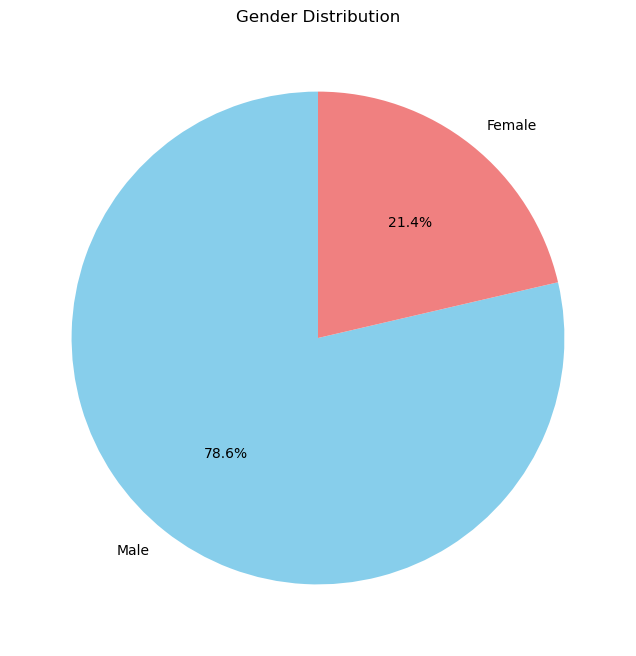

In [26]:
# Create a pie chart to visualize gender distribution
plt.figure(figsize=(8,8))  # Set the figure size
plt.pie(gender_count, 
        labels=gender_count.index,  # Use gender labels for the slices
        autopct='%1.1f%%',          # Show the percentage on the slices
        startangle=90,              # Start the pie chart from 90 degrees
        colors=['skyblue', 'lightcoral'])  # Define colors for the slices
plt.title('Gender Distribution')  # Set the title of the pie chart
plt.show()  # Display the pie chart

### Annual Income Distribution

C:\Users\ADM\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


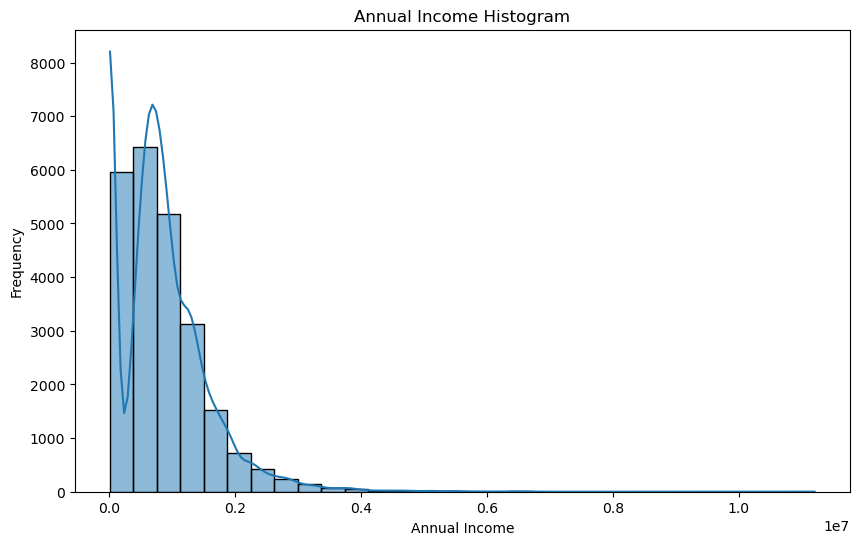

In [27]:
# Create a histogram to visualize the distribution of annual income
plt.figure(figsize=(10, 6))  # Set the figure size
sns.histplot(df['Annual Income'], bins=30, kde=True)  # 'bins' parameter determines the number of bins for the histogram; 'kde=True' adds a Kernel Density Estimate curve
plt.title('Annual Income Histogram')  # Set the title of the histogram
plt.xlabel('Annual Income')  # Set the x-axis label
plt.ylabel('Frequency')  # Set the y-axis label
plt.show()  # Display the histogram

## Purchase Patterns

### Most Popular Models

In [28]:
# Count the number of occurrences for each car model
model_counts = df['Model'].value_counts()

# Select the top 25 most frequent car models
top_25_models = model_counts.head(25)

# Print the counts of all car models
print(model_counts)

Model
Diamante         418
Silhouette       411
Prizm            411
Passat           391
Ram Pickup       383
                ... 
Mirage            19
Alero             18
RX300             15
Avalon            15
Sebring Conv.     10
Name: count, Length: 154, dtype: int64


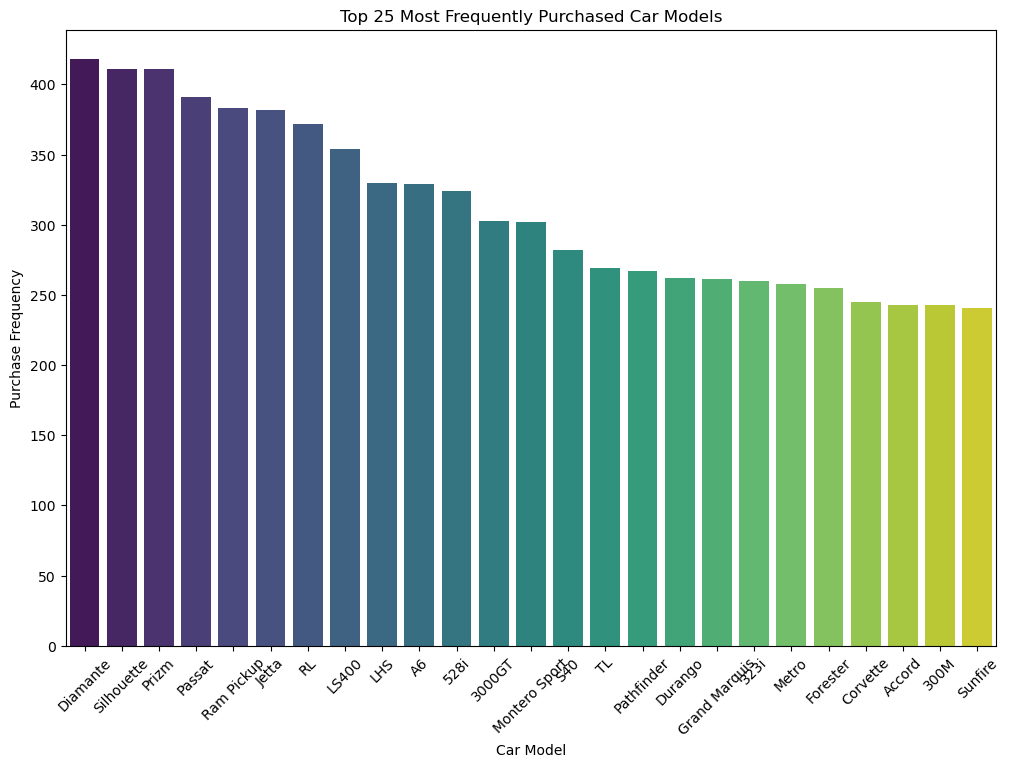

In [39]:
# Create a bar plot to visualize the top 25 most frequently purchased car models
plt.figure(figsize=(12, 8))  # Set the figure size
sns.barplot(x=top_25_models.index, y=top_25_models.values, palette='viridis')  # Use top 25 car models and their frequencies, with a color palette
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title('Top 25 Most Frequently Purchased Car Models')  # Set the title of the bar plot
plt.xlabel('Car Model')  # Set the x-axis label
plt.ylabel('Purchase Frequency')  # Set the y-axis label
plt.show()  # Display the bar plot

### Price Analysis

In [30]:
# Calculate the average price for each car model
average_prices = df.groupby('Model')['Price'].mean()

# Sort the average prices in descending order
sorted_average_prices = average_prices.sort_values(ascending=False)

# Display the sorted average prices
sorted_average_prices

Model
Catera     56836.933333
DeVille    46154.050000
Contour    45309.079646
Integra    44604.000000
Tacoma     44576.743017
               ...     
Montero    16035.000000
C-Class    14538.414474
Escort     12901.092105
Cirrus     12727.243243
Mirage      9063.368421
Name: Price, Length: 154, dtype: float64

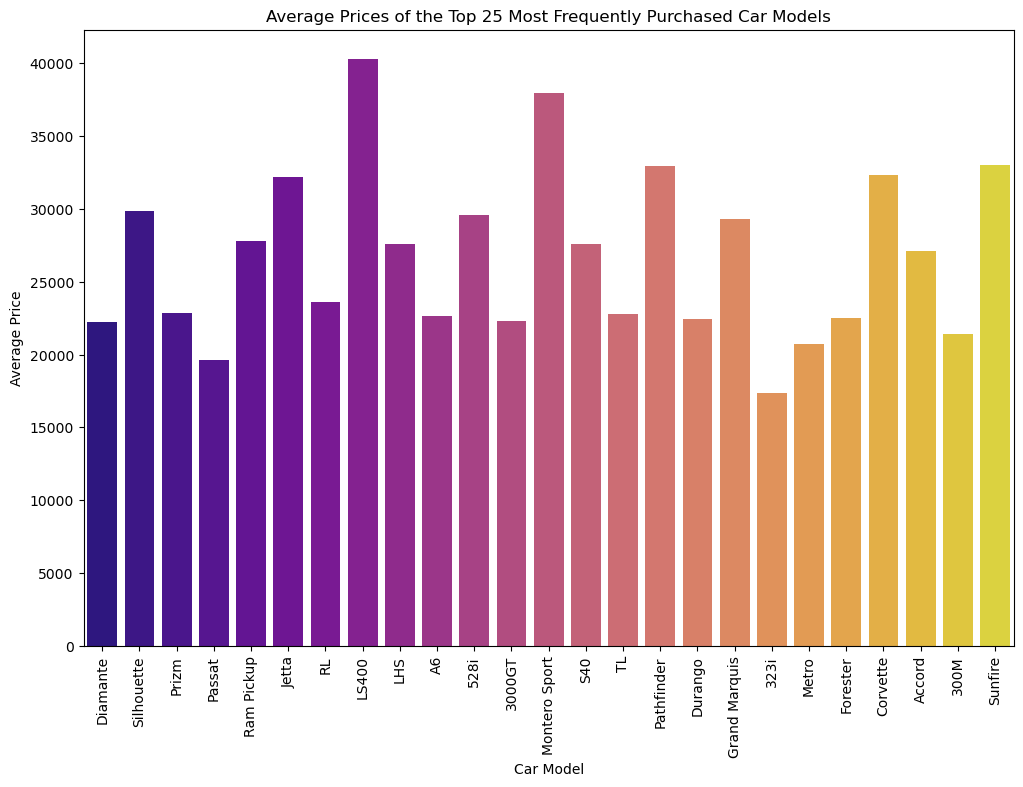

In [40]:
# Select the average prices for the top 25 most frequently purchased car models
top_25_avg_prices = average_prices.loc[top_25_models.index]

# Create a bar plot to visualize the average prices of the top 25 most frequently purchased car models
plt.figure(figsize=(12, 8))  # Set the figure size
sns.barplot(x=top_25_avg_prices.index, y=top_25_avg_prices.values, palette='plasma')  # Use top 25 average prices with a color palette
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Average Prices of the Top 25 Most Frequently Purchased Car Models')  # Set the title of the bar plot
plt.xlabel('Car Model')  # Set the x-axis label
plt.ylabel('Average Price')  # Set the y-axis label
plt.show()  # Display the bar plot

### Body Style Preferences

In [32]:
# Count the number of occurrences for each body style
body_style_counts = df['Body Style'].value_counts()

# Print the counts of each body style
print(body_style_counts)

Body Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64


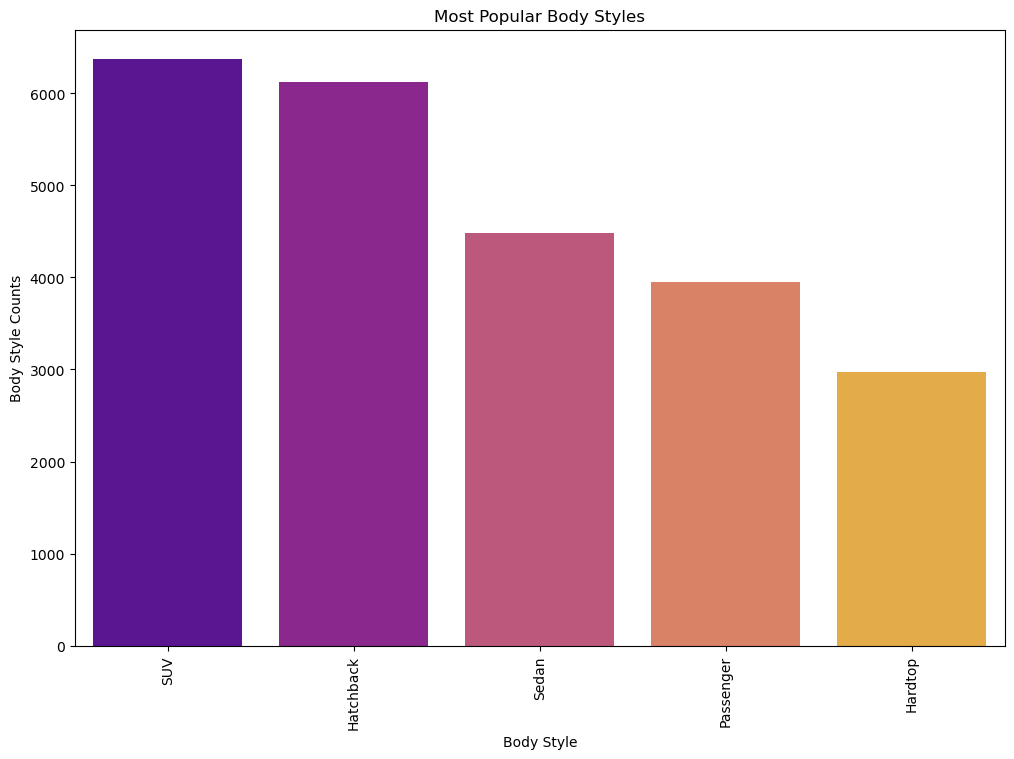

In [33]:
# Create a bar plot to visualize the counts of different body styles
plt.figure(figsize=(12, 8))  # Set the figure size
sns.barplot(x=body_style_counts.index, y=body_style_counts.values, palette='plasma')  # Use body style counts with a color palette
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Most Popular Body Styles')  # Set the title of the bar plot
plt.xlabel('Body Style')  # Set the x-axis label
plt.ylabel('Body Style Counts')  # Set the y-axis label
plt.show()  # Display the bar plot

## Dealer Analysis

### Sales by Dealer

In [34]:
# Count the number of sales for each dealer
dealer_sales_count = df['Dealer_Name'].value_counts()

# Display the counts of sales for each dealer
dealer_sales_count

Dealer_Name
Progressive Shippers Cooperative Association No    1318
Rabun Used Car Sales                               1313
Race Car Help                                      1253
Saab-Belle Dodge                                   1251
Star Enterprises Inc                               1249
Tri-State Mack Inc                                 1249
Ryder Truck Rental and Leasing                     1248
U-Haul CO                                          1247
Scrivener Performance Engineering                  1246
Suburban Ford                                      1243
Nebo Chevrolet                                      633
Pars Auto Sales                                     630
New Castle Ford Lincoln Mercury                     629
McKinney Dodge Chrysler Jeep                        629
Hatfield Volkswagen                                 629
Gartner Buick Hyundai Saab                          628
Pitre Buick-Pontiac-Gmc of Scottsdale               628
Capitol KIA                         

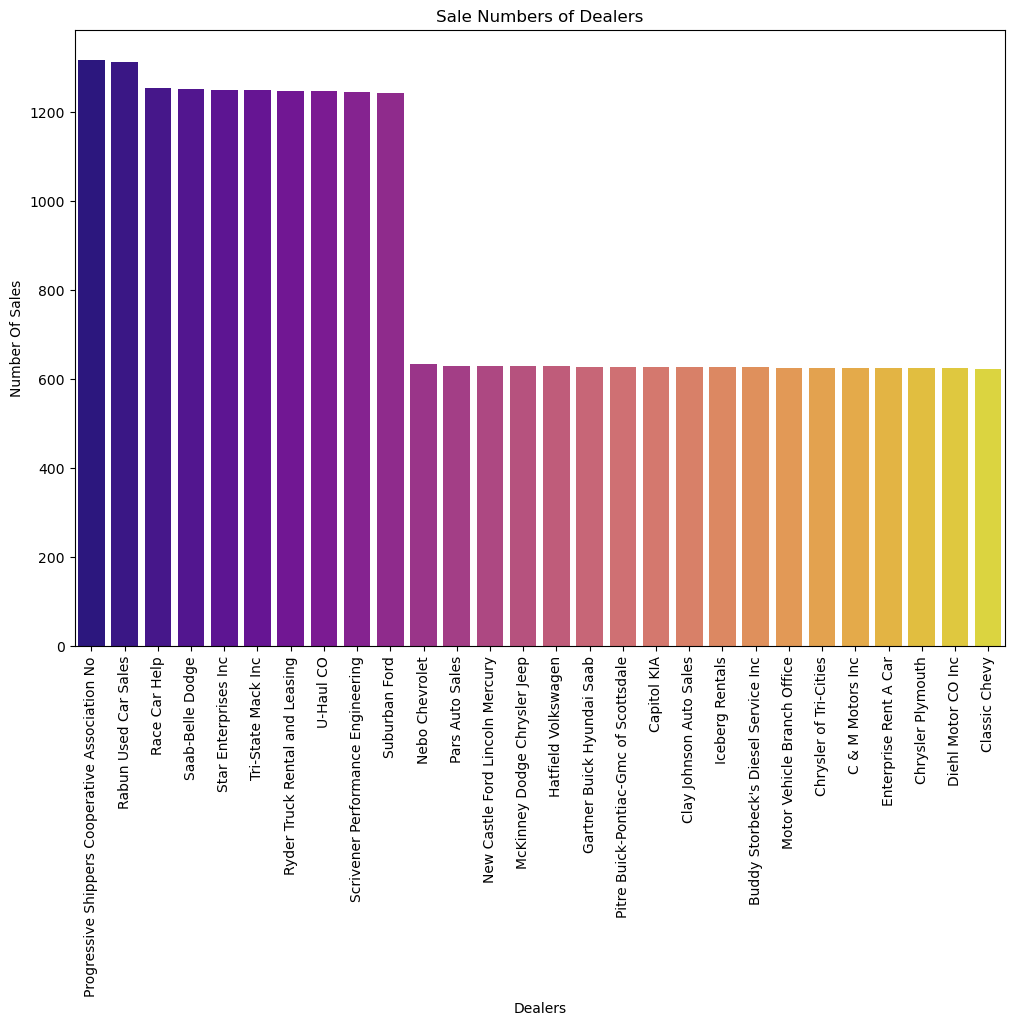

In [35]:
# Create a bar plot to visualize the number of sales for each dealer
plt.figure(figsize=(12, 8))  # Set the figure size
sns.barplot(x=dealer_sales_count.index, y=dealer_sales_count.values, palette='plasma')  # Use dealer sales counts with a color palette
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title('Sale Numbers of Dealers')  # Set the title of the bar plot
plt.xlabel('Dealers')  # Set the x-axis label
plt.ylabel('Number Of Sales')  # Set the y-axis label
plt.show()  # Display the bar plot

### Dealer Regions

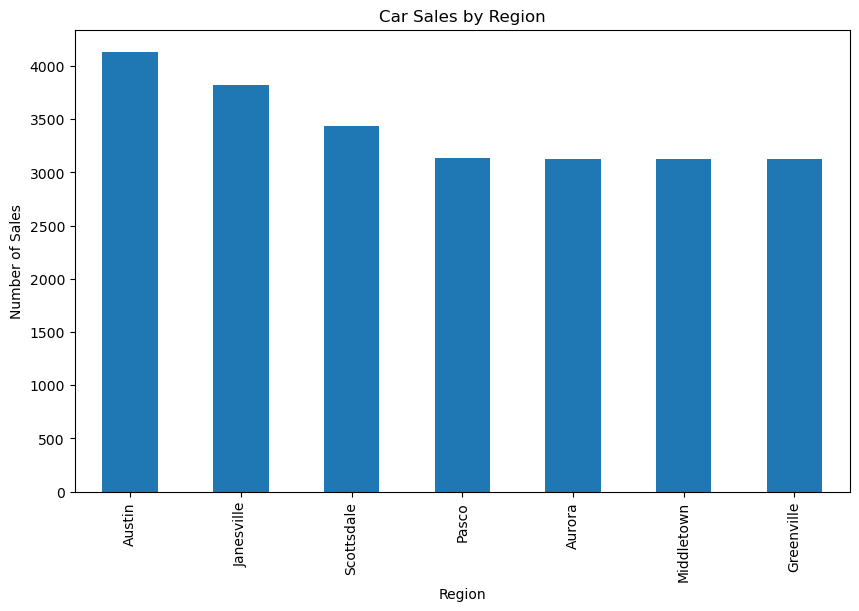

In [36]:
# Count the number of sales for each dealer region
region_sales = df['Dealer_Region'].value_counts()

# Create a bar plot to visualize car sales by region
plt.figure(figsize=(10, 6))  # Set the figure size
region_sales.plot(kind='bar')  # Create a bar plot
plt.title('Car Sales by Region')  # Set the title of the bar plot
plt.xlabel('Region')  # Set the x-axis label
plt.ylabel('Number of Sales')  # Set the y-axis label
plt.show()  # Display the bar plot

## Customer Segmentation

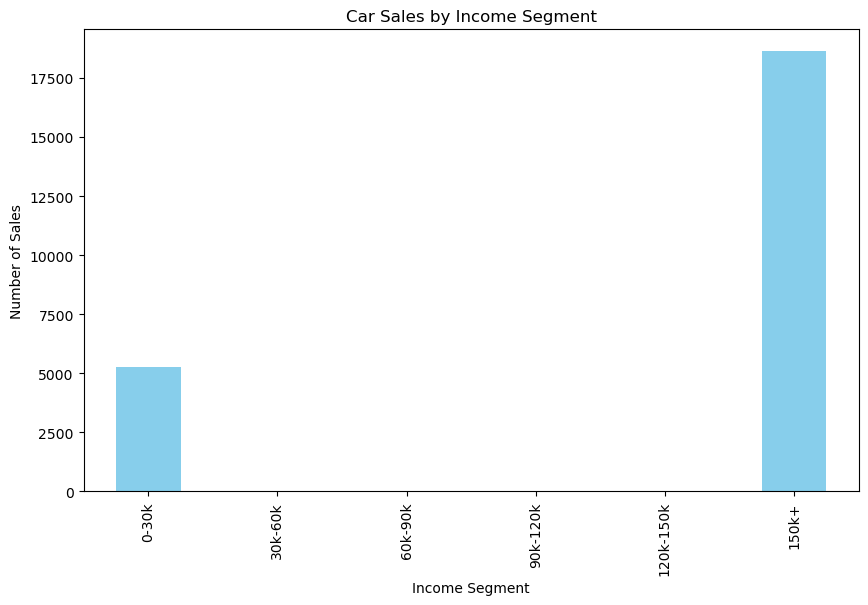

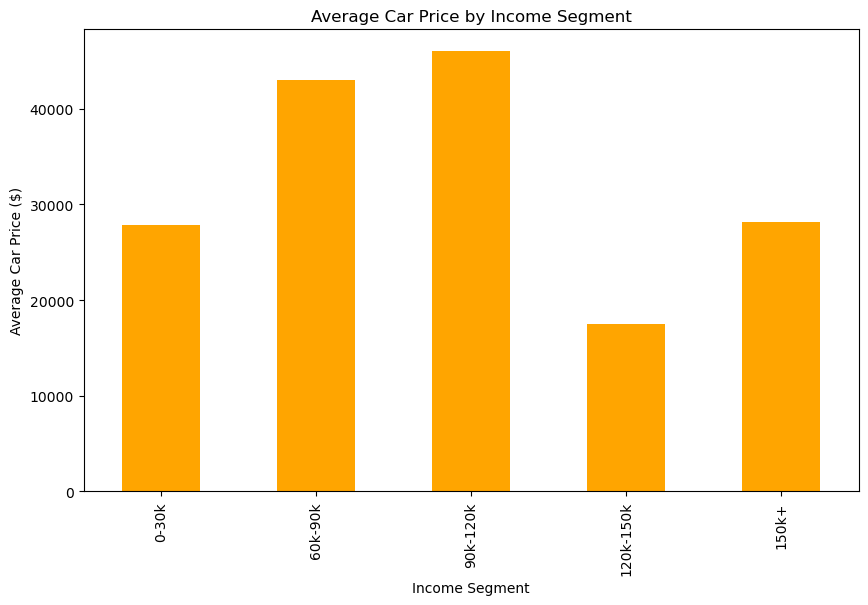

In [37]:
# Define bins for income segments and labels for each segment
bins = [0, 30000, 60000, 90000, 120000, 150000, df['Annual Income'].max()]
labels = ['0-30k', '30k-60k', '60k-90k', '90k-120k', '120k-150k', '150k+']

# Create a new column 'Income Segment' that categorizes 'Annual Income' into the defined bins
df['Income Segment'] = pd.cut(df['Annual Income'], bins=bins, labels=labels)

# Count the number of sales in each income segment and sort the counts by index
income_segment_sales = df['Income Segment'].value_counts().sort_index()

# Create a bar plot to visualize car sales by income segment
plt.figure(figsize=(10, 6))  # Set the figure size
income_segment_sales.plot(kind='bar', color='skyblue')  # Create a bar plot with specified color
plt.title('Car Sales by Income Segment')  # Set the title of the bar plot
plt.xlabel('Income Segment')  # Set the x-axis label
plt.ylabel('Number of Sales')  # Set the y-axis label
plt.show()  # Display the bar plot

# Calculate the average car price for each income segment
segment_price = df.groupby('Income Segment', observed=True)['Price'].mean()

# Create a bar plot to visualize the average car price by income segment
plt.figure(figsize=(10, 6))  # Set the figure size
segment_price.plot(kind='bar', color='orange')  # Create a bar plot with specified color
plt.title('Average Car Price by Income Segment')  # Set the title of the bar plot
plt.xlabel('Income Segment')  # Set the x-axis label
plt.ylabel('Average Car Price ($)')  # Set the y-axis label
plt.show()  # Display the bar plot

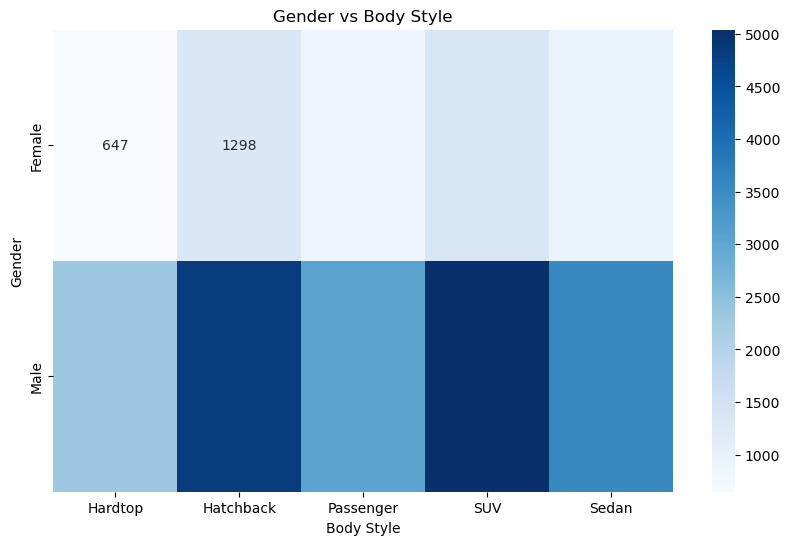

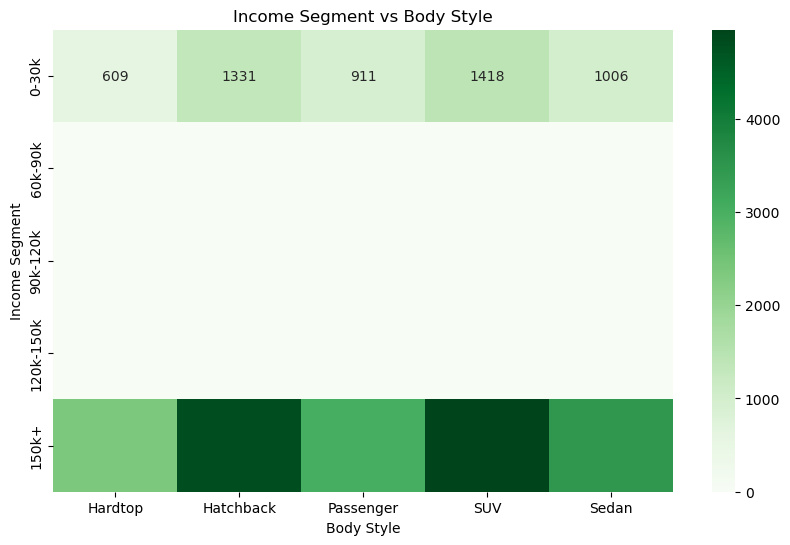

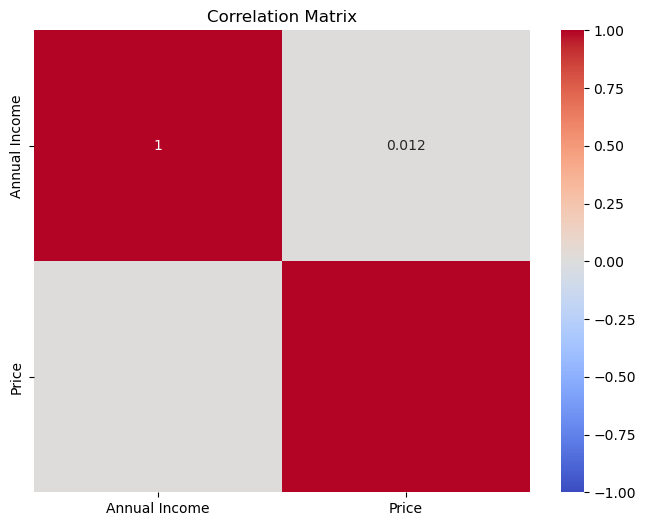

,Annual Income,Price
Annual Income,1.000000,0.012065
Price,0.012065,1.000000


In [38]:
# Create a cross-tabulation of 'Gender' vs 'Body Style'
gender_body_style = pd.crosstab(df['Gender'], df['Body Style'])

# Create a heatmap to visualize the relationship between gender and body style
plt.figure(figsize=(10, 6))  # Set the figure size
sns.heatmap(gender_body_style, annot=True, fmt='d', cmap='Blues')  # Display counts with annotations and a blue color map
plt.title('Gender vs Body Style')  # Set the title of the heatmap
plt.xlabel('Body Style')  # Set the x-axis label
plt.ylabel('Gender')  # Set the y-axis label
plt.show()  # Display the heatmap

# Create a cross-tabulation of 'Income Segment' vs 'Body Style'
income_body_style = pd.crosstab(df['Income Segment'], df['Body Style'])

# Create a heatmap to visualize the relationship between income segments and body styles
plt.figure(figsize=(10, 6))  # Set the figure size
sns.heatmap(income_body_style, annot=True, fmt='d', cmap='Greens')  # Display counts with annotations and a green color map
plt.title('Income Segment vs Body Style')  # Set the title of the heatmap
plt.xlabel('Body Style')  # Set the x-axis label
plt.ylabel('Income Segment')  # Set the y-axis label
plt.show()  # Display the heatmap

# Define the numerical columns to be analyzed
numerical_columns = ['Annual Income', 'Price']

# Calculate the correlation matrix for the numerical columns
correlation_matrix = df[numerical_columns].corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)  # Display correlation coefficients with annotations
plt.title('Correlation Matrix')  # Set the title of the heatmap
plt.show()  # Display the heatmap

# Display the correlation matrix
correlation_matrix